<a href="https://colab.research.google.com/github/cecile-macaire/econometrics/blob/main/econometrics_panel_pset_code_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Econometrics II Panel Data Problem Set — Python Code - Cecile Macaire

This notebook contains code for the parts that require computation:

- **Exercise 1(c):** Monte Carlo comparing FD, WG, and unfeasible optimal IV.
- **Exercise 2(c)-(d):** Minimum-distance estimates for the income process and full income-consumption system using `ps1_data.csv`.
- **Exercise 3(c):** Test for correlated random coefficients using the same data.




In [31]:

# ============================================================
# 0. Imports and settings
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import statsmodels.api as sm
from pathlib import Path

np.set_printoptions(precision=4, suppress=True)

# Change this path if needed in Colab
#DATA_PATH = "ps1_data.csv"
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/ps1_data.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



# Exercise 1(c): Monte Carlo simulation

The pset asks for `nMC = 10000`, `N = 2000`, `T = 7`.  
That can be slow in Colab. I set `nMC = 500` by default so you can test that the code works. For the final run, change it to `10000`.


In [32]:

# ============================================================
# Exercise 1(c): helper functions
# ============================================================

def fd_transform(arr):
    """First differences along time axis. arr shape: (N,T,...)"""
    return arr[:, 1:, ...] - arr[:, :-1, ...]


def within_transform(arr):
    """Within-demean along time axis. arr shape: (N,T,...)"""
    return arr - arr.mean(axis=1, keepdims=True)


def iv_scalar_stacked(y, x, Z):
    """
    Scalar IV/2SLS estimator with one endogenous regressor.

    y: shape (N,T)
    x: shape (N,T)
    Z: shape (N,T,r)

    Returns beta_hat using stacked observations and instruments.
    Formula: beta = (x' Pz x)^(-1) x' Pz y
    Efficient implementation:
        x'Pz y = (Z'x)' (Z'Z)^(-1) (Z'y)
    """
    yv = y.reshape(-1, 1)
    xv = x.reshape(-1, 1)
    Zv = Z.reshape(-1, Z.shape[-1])

    ZTZ = Zv.T @ Zv
    ZTx = Zv.T @ xv
    ZTy = Zv.T @ yv

    num = (ZTx.T @ np.linalg.solve(ZTZ, ZTy)).item()
    den = (ZTx.T @ np.linalg.solve(ZTZ, ZTx)).item()
    beta_hat = num / den
    return beta_hat


def fd_iv(y, x, z):
    """FD estimator using Δz as instruments."""
    dy = fd_transform(y)
    dx = fd_transform(x)
    dz = fd_transform(z)
    return iv_scalar_stacked(dy, dx, dz)


def wg_iv(y, x, z):
    """WG estimator using z_it - zbar_i as instruments."""
    yw = within_transform(y)
    xw = within_transform(x)
    zw = within_transform(z)
    return iv_scalar_stacked(yw, xw, zw)


def make_sigma_v(T, rho, sigma2):
    """
    Covariance matrix of v_t given:
        v_1 variance = sigma2
        v_t = rho v_{t-1} + eps_t
        Var(eps_t) = sigma2
    """
    Sigma = np.zeros((T, T))
    var = np.zeros(T)
    var[0] = sigma2
    for t in range(1, T):
        var[t] = rho**2 * var[t-1] + sigma2

    for t in range(T):
        for s in range(T):
            if t >= s:
                Sigma[t, s] = (rho ** (t-s)) * var[s]
            else:
                Sigma[t, s] = Sigma[s, t]
    return Sigma


def orthogonal_to_ones_matrix(T):
    """
    Return Q, a (T-1)xT matrix with Q 1_T = 0 and QQ' = I.
    """
    one = np.ones((T, 1))
    A = np.eye(T) - one @ one.T / T
    vals, vecs = np.linalg.eigh(A)
    Q = vecs[:, vals > 1e-10].T
    return Q


def optimal_iv(y, x, z, Pi, rho, sigma2):
    """
    Unfeasible optimal IV estimator under linear first stage E[x_it|z_i]=Pi'z_it.

    y: (N,T)
    x: (N,T)
    z: (N,T,r)
    Pi: (r,)
    """
    N, T = y.shape
    Q = orthogonal_to_ones_matrix(T)
    Sigma = make_sigma_v(T, rho, sigma2)
    Omega = Q @ Sigma @ Q.T
    Omega_inv = np.linalg.inv(Omega)

    num = 0.0
    den = 0.0
    for i in range(N):
        yq = Q @ y[i, :]
        xhat_levels = z[i, :, :] @ Pi
        xhat_q = Q @ xhat_levels
        num += xhat_q.T @ Omega_inv @ yq
        den += xhat_q.T @ Omega_inv @ xhat_q

    return float(num / den)


def simulate_panel_ex1(N=2000, T=7, beta=1.0, rdim=2, Pi=np.array([1.0, 1.0]),
                       sigma2=1.0, rho=0.0, alpha=0.4, rng=None):
    """
    Simulate one sample for Exercise 1.
    """
    if rng is None:
        rng = np.random.default_rng()

    z = rng.normal(size=(N, T, rdim))

    v = np.zeros((N, T))
    eps = np.zeros((N, T))
    v[:, 0] = rng.normal(scale=np.sqrt(sigma2), size=N)
    eps[:, 0] = v[:, 0]

    for t in range(1, T):
        eps[:, t] = rng.normal(scale=np.sqrt(sigma2), size=N)
        v[:, t] = rho * v[:, t-1] + eps[:, t]

    u = rng.normal(scale=np.sqrt(sigma2), size=(N, T))

    x = z @ Pi + alpha * eps + np.sqrt(1 - alpha**2) * u

    eta = rng.normal(size=N)
    y = beta * x + eta[:, None] + v
    return y, x, z


def monte_carlo_ex1(rhos=None, nMC=500, N=2000, T=7, seed=12345,
                    Pi=np.array([1.0, 1.0]), sigma2=1.0, alpha=0.4,
                    beta=1.0):
    """
    Runs Monte Carlo and returns dataframe of N-scaled sampling variances.
    Change nMC to 10000 for the final pset run.
    """
    if rhos is None:
        rhos = np.round(np.arange(-0.2, 1.0001, 0.2), 2)

    rng = np.random.default_rng(seed)
    rows = []

    for rho in rhos:
        print(f"Running rho = {rho}")
        b_fd = np.empty(nMC)
        b_wg = np.empty(nMC)
        b_opt = np.empty(nMC)

        for m in range(nMC):
            y, x, z = simulate_panel_ex1(
                N=N, T=T, beta=beta, rdim=len(Pi), Pi=Pi,
                sigma2=sigma2, rho=rho, alpha=alpha, rng=rng
            )
            b_fd[m] = fd_iv(y, x, z)
            b_wg[m] = wg_iv(y, x, z)
            b_opt[m] = optimal_iv(y, x, z, Pi=Pi, rho=rho, sigma2=sigma2)

        rows.append({
            "rho": rho,
            "FD": N * np.var(b_fd, ddof=1),
            "WG": N * np.var(b_wg, ddof=1),
            "Optimal IV": N * np.var(b_opt, ddof=1),
            "FD_mean": np.mean(b_fd),
            "WG_mean": np.mean(b_wg),
            "Optimal_IV_mean": np.mean(b_opt)
        })

    return pd.DataFrame(rows)


def plot_mc_variances(results, title="Monte Carlo variances scaled by N"):
    plt.figure(figsize=(8, 5))
    for col in ["FD", "WG", "Optimal IV"]:
        plt.plot(results["rho"], results[col], marker="o", label=col)

    plt.xlabel("rho")
    plt.ylabel("N x Var(beta_hat)")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Running rho = -0.2
Running rho = 0.0
Running rho = 0.2
Running rho = 0.4
Running rho = 0.6
Running rho = 0.8
Running rho = 1.0


,rho,FD,WG,Optimal IV,FD_mean,WG_mean,Optimal_IV_mean
0,-0.2,0.163596,0.096542,0.239525,1.000103,1.000067,1.000095
1,0.0,0.126564,0.084345,0.234848,1.000006,1.000384,1.000450
2,0.2,0.086681,0.079347,0.223198,1.000076,0.999974,0.999869
3,0.4,0.077688,0.080968,0.227474,1.000041,0.999819,0.999118
4,0.6,0.062311,0.093718,0.250696,1.000099,0.999980,0.999943
5,0.8,0.046027,0.086503,0.250393,1.000128,0.999864,0.999907
6,1.0,0.041619,0.111958,0.326338,1.000128,1.000311,1.001188


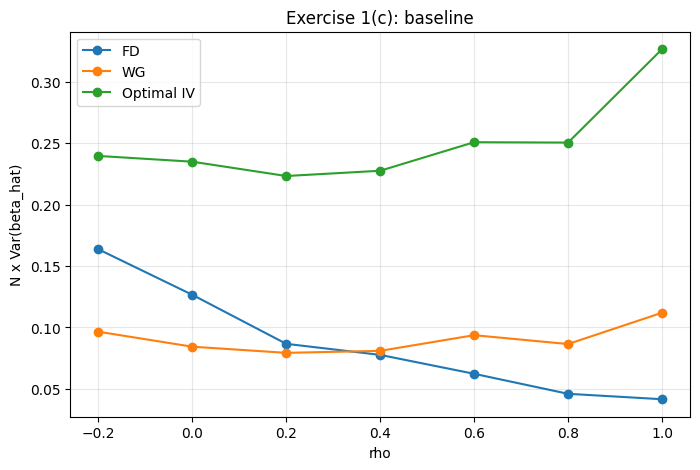

In [33]:

# ============================================================
# Exercise 1(c): run baseline Monte Carlo
# ============================================================

# For testing:
results_baseline = monte_carlo_ex1(nMC=500, N=2000, T=7, seed=12345)

# For final run, use:
# results_baseline = monte_carlo_ex1(nMC=10000, N=2000, T=7, seed=12345)

display(results_baseline)
plot_mc_variances(results_baseline, title="Exercise 1(c): baseline")


Running rho = -0.2
Running rho = 0.0
Running rho = 0.2
Running rho = 0.4
Running rho = 0.6
Running rho = 0.8
Running rho = 1.0


,rho,FD,WG,Optimal IV,FD_mean,WG_mean,Optimal_IV_mean
0,-0.2,0.152849,0.085861,0.176241,1.000218,1.000243,1.000642
1,0.0,0.101403,0.077851,0.179283,1.000154,1.000011,1.000400
2,0.2,0.090256,0.085462,0.169475,0.999549,0.999419,0.999011
3,0.4,0.071329,0.078474,0.192117,0.999775,0.999646,0.999140
4,0.6,0.058704,0.081020,0.207262,1.000189,1.000115,0.999719
5,0.8,0.048748,0.082663,0.190957,0.999789,0.999736,0.999424
6,1.0,0.044800,0.112732,0.322564,1.000295,1.000125,0.999766


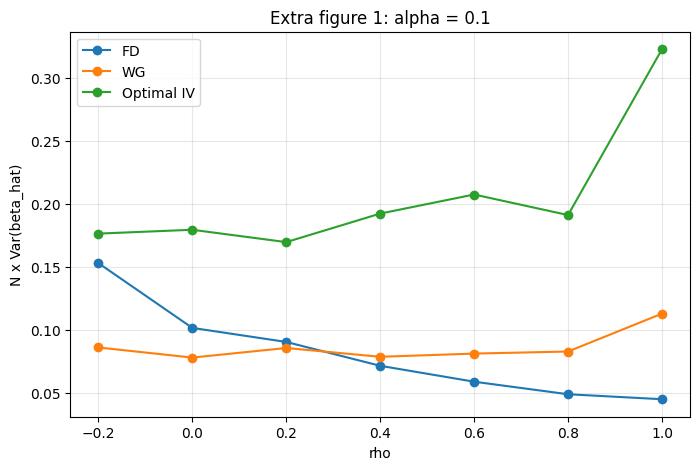

Running rho = -0.2
Running rho = 0.0
Running rho = 0.2
Running rho = 0.4
Running rho = 0.6
Running rho = 0.8
Running rho = 1.0


,rho,FD,WG,Optimal IV,FD_mean,WG_mean,Optimal_IV_mean
0,-0.2,0.039010,0.021842,0.060628,1.000293,1.000320,1.000654
1,0.0,0.030388,0.022423,0.061621,1.000068,1.000085,1.000177
2,0.2,0.021281,0.020096,0.057315,0.999783,0.999828,0.999712
3,0.4,0.019302,0.019792,0.058810,0.999921,0.999825,0.999688
4,0.6,0.015144,0.020229,0.055488,0.999984,0.999985,0.999879
5,0.8,0.012163,0.020506,0.062348,0.999831,0.999719,1.000008
6,1.0,0.010224,0.028714,0.080450,0.999942,0.999843,0.999365


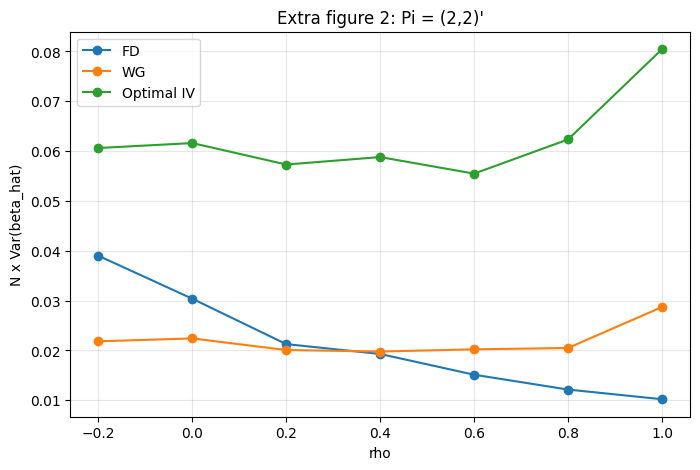

Running rho = -0.2
Running rho = 0.0
Running rho = 0.2
Running rho = 0.4
Running rho = 0.6
Running rho = 0.8
Running rho = 1.0


,rho,FD,WG,Optimal IV,FD_mean,WG_mean,Optimal_IV_mean
0,-0.2,0.300013,0.179643,0.513522,0.999302,0.999285,0.999224
1,0.0,0.219120,0.162158,0.478929,0.999754,0.999610,0.999398
2,0.2,0.176513,0.158137,0.470641,1.000441,1.000341,1.000615
3,0.4,0.147036,0.157438,0.449281,1.000377,1.000653,1.000679
4,0.6,0.118299,0.167836,0.499864,0.999825,0.999493,0.999121
5,0.8,0.093534,0.178349,0.603549,1.000050,1.000361,0.999551
6,1.0,0.080543,0.215903,0.738194,0.999875,0.999821,1.000177


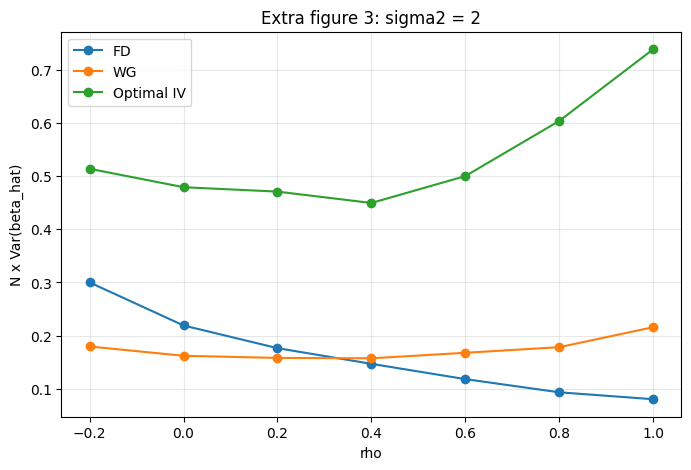

In [34]:

# ============================================================
# Exercise 1(c): optional extra experiments
# No more than 3 extra figures, as requested in the pset.
# ============================================================

# These can take time. Uncomment one at a time if needed.

results_alpha_low = monte_carlo_ex1(nMC=500, N=2000, T=7, seed=2026, alpha=0.1)
display(results_alpha_low)
plot_mc_variances(results_alpha_low, title="Extra figure 1: alpha = 0.1")

results_pi_strong = monte_carlo_ex1(nMC=500, N=2000, T=7, seed=2027, Pi=np.array([2.0, 2.0]))
display(results_pi_strong)
plot_mc_variances(results_pi_strong, title="Extra figure 2: Pi = (2,2)'")

results_sigma_high = monte_carlo_ex1(nMC=500, N=2000, T=7, seed=2028, sigma2=2.0)
display(results_sigma_high)
plot_mc_variances(results_sigma_high, title="Extra figure 3: sigma2 = 2")




The Monte Carlo results show that the relative efficiency of the FD and WG estimators depends on the serial correlation parameter $\rho$.

When $\rho$ is low (weak serial correlation), the within-groups (WG) estimator tends to be more efficient, as it uses more variation in the data. However, as $\rho$ increases and the error term becomes more persistent, the first-difference (FD) estimator performs better and becomes relatively more efficient.

Intuitively, when shocks are highly persistent, differencing removes much of the serial correlation, improving efficiency. In contrast, when errors are weakly correlated, the WG estimator retains more useful variation and performs better.

In practice, the choice between FD and WG should depend on prior knowledge about the persistence of the error term. If the researcher expects strong serial correlation, FD is preferable; otherwise, WG may be more efficient.

---



# Exercise 2: Income and consumption covariance matching

The dataset is wide: `income_1999`, ..., `income_2009`, and similarly for consumption, wealth, age.

We compute income and consumption growth, build sample covariance matrices, then estimate parameters by minimum distance.


In [35]:

# ============================================================
# Exercise 2: load and prepare data
# ============================================================

df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())

years = [1999, 2001, 2003, 2005, 2007, 2009]

income_cols = [f"income_{y}" for y in years]
cons_cols = [f"consumption_{y}" for y in years]
wealth_cols = [f"wealth_{y}" for y in years]
age_cols = [f"age_{y}" for y in years]

Y = df[income_cols].to_numpy(dtype=float)
C = df[cons_cols].to_numpy(dtype=float)
AGE = df[age_cols].to_numpy(dtype=float)
WEALTH = df[wealth_cols].to_numpy(dtype=float)

dY = np.diff(Y, axis=1)
dC = np.diff(C, axis=1)

print("Income growth matrix shape:", dY.shape)
print("Consumption growth matrix shape:", dC.shape)

def make_s_alternating(dY, dC):
    N, m = dY.shape
    S = np.empty((N, 2*m))
    S[:, 0::2] = dY
    S[:, 1::2] = dC
    return S

S_alt = make_s_alternating(dY, dC)
S_block = np.column_stack([dY, dC])

Omega_hat_block = np.cov(S_block, rowvar=False, ddof=1)
Omega_hat_y = np.cov(dY, rowvar=False, ddof=1)

print("Sample covariance income growth:")
display(pd.DataFrame(Omega_hat_y, index=years[1:], columns=years[1:]))


(792, 24)


,income_1999,income_2001,income_2003,income_2005,income_2007,income_2009,consumption_1999,consumption_2001,consumption_2003,consumption_2005,...,wealth_2003,wealth_2005,wealth_2007,wealth_2009,age_1999,age_2001,age_2003,age_2005,age_2007,age_2009
0,0.281135,0.473020,0.309249,-0.216575,-0.377518,-0.381334,0.070637,0.141996,0.340238,1.040031,...,0.340238,1.040031,0.265098,0.239944,35,37,39,41,43,45
1,0.883510,-0.103408,-0.088778,0.186968,-0.328921,0.060208,0.226552,0.273817,0.547570,0.642049,...,0.547570,0.642049,0.132267,0.403058,43,45,47,49,51,53
2,0.063431,0.149469,0.407620,0.682703,-0.477465,-0.825758,0.344430,-0.279328,-0.174459,0.087367,...,-0.174459,0.087367,-0.053340,0.075330,49,51,53,55,57,59
3,-0.280682,-0.173946,0.054954,-0.148393,-0.222265,-0.275904,-0.640451,-0.654601,-0.407360,-0.436682,...,-0.407360,-0.436682,-0.325058,-0.745890,36,38,40,42,44,46
4,-0.276030,-0.080856,-0.008528,0.172011,0.058581,0.227393,-0.398535,-0.053338,-0.048951,0.355645,...,-0.048951,0.355645,0.231648,-0.124438,40,42,44,46,48,50


Income growth matrix shape: (792, 5)
Consumption growth matrix shape: (792, 5)
Sample covariance income growth:


,2001,2003,2005,2007,2009
2001,0.126538,-0.040414,-0.001069,-0.003720,0.003677
2003,-0.040414,0.181423,-0.099277,0.003674,0.002795
2005,-0.001069,-0.099277,0.189446,-0.058475,-0.002035
2007,-0.003720,0.003674,-0.058475,0.152093,-0.026906
2009,0.003677,0.002795,-0.002035,-0.026906,0.165880


In [36]:

# ============================================================
# Exercise 2: model-implied covariance matrices
# ============================================================

def omega_income(theta_y, m=5):
    """
    Income-growth covariance matrix.
    theta_y = [sigma_eta2, psi_eps, sigma_eps2]
    """
    sigma_eta2, psi_eps, sigma_eps2 = theta_y
    Om = np.zeros((m, m))

    var_dy = sigma_eta2 + sigma_eps2 * (2 + 2*psi_eps**2 - 2*psi_eps)
    cov_lag1 = -sigma_eps2 * (1 - psi_eps)**2
    cov_lag2 = -psi_eps * sigma_eps2

    for i in range(m):
        for j in range(m):
            lag = abs(i-j)
            if lag == 0:
                Om[i, j] = var_dy
            elif lag == 1:
                Om[i, j] = cov_lag1
            elif lag == 2:
                Om[i, j] = cov_lag2
            else:
                Om[i, j] = 0.0
    return Om


def omega_full(theta, m=5):
    """
    Full covariance matrix for [dy_2,...,dy_T, dc_2,...,dc_T].
    theta = [sigma_eta2, psi_eps, sigma_eps2, alpha, beta, psi_c, sigma_c]
    """
    sigma_eta2, psi_eps, sigma_eps2, alpha, beta, psi_c, sigma_c = theta
    sigma_c2 = sigma_c**2

    Oyy = omega_income([sigma_eta2, psi_eps, sigma_eps2], m=m)

    Occ = np.zeros((m, m))
    var_dc = alpha**2 * sigma_eta2 + alpha**2 * beta**2 * sigma_eps2 + (1 + psi_c**2) * sigma_c2
    cov_dc_lag1 = psi_c * sigma_c2

    for i in range(m):
        for j in range(m):
            lag = abs(i-j)
            if lag == 0:
                Occ[i, j] = var_dc
            elif lag == 1:
                Occ[i, j] = cov_dc_lag1
            else:
                Occ[i, j] = 0.0

    Oyc = np.zeros((m, m))
    for i in range(m):
        for j in range(m):
            if j == i:
                Oyc[i, j] = alpha * sigma_eta2 + alpha * beta * sigma_eps2
            elif j == i - 1:
                Oyc[i, j] = alpha * beta * (psi_eps - 1) * sigma_eps2
            elif j == i - 2:
                Oyc[i, j] = -alpha * beta * psi_eps * sigma_eps2
            else:
                Oyc[i, j] = 0.0

    top = np.column_stack([Oyy, Oyc])
    bottom = np.column_stack([Oyc.T, Occ])
    return np.row_stack([top, bottom])


def vech(A):
    idx = np.tril_indices_from(A)
    return A[idx]


def md_objective_income(raw_params, Omega_hat):
    sigma_eta2 = np.exp(raw_params[0])
    psi_eps = raw_params[1]
    sigma_eps2 = np.exp(raw_params[2])

    theta_y = np.array([sigma_eta2, psi_eps, sigma_eps2])
    diff = vech(Omega_hat) - vech(omega_income(theta_y, m=Omega_hat.shape[0]))
    return diff @ diff


def estimate_income_md(Omega_hat):
    var0 = max(np.mean(np.diag(Omega_hat)), 1e-4)
    x0 = np.array([np.log(var0/2), 0.0, np.log(var0/2)])

    res = minimize(
        md_objective_income, x0, args=(Omega_hat,),
        method="Nelder-Mead",
        options={"maxiter": 20000, "xatol": 1e-10, "fatol": 1e-10}
    )

    raw = res.x
    theta_hat = np.array([np.exp(raw[0]), raw[1], np.exp(raw[2])])
    return theta_hat, res


def md_objective_full(raw_params, Omega_hat):
    sigma_eta2 = np.exp(raw_params[0])
    psi_eps = raw_params[1]
    sigma_eps2 = np.exp(raw_params[2])
    alpha = raw_params[3]
    beta = raw_params[4]
    psi_c = raw_params[5]
    sigma_c = np.exp(raw_params[6])

    theta = np.array([sigma_eta2, psi_eps, sigma_eps2, alpha, beta, psi_c, sigma_c])
    diff = vech(Omega_hat) - vech(omega_full(theta, m=Omega_hat.shape[0]//2))
    return diff @ diff


def estimate_full_md(Omega_hat, theta_y_start=None):
    if theta_y_start is None:
        theta_y_start, _ = estimate_income_md(Omega_hat[:5, :5])

    sigma_eta2, psi_eps, sigma_eps2 = theta_y_start
    x0 = np.array([
        np.log(max(sigma_eta2, 1e-6)),
        psi_eps,
        np.log(max(sigma_eps2, 1e-6)),
        0.8,
        0.2,
        0.0,
        np.log(0.1)
    ])

    res = minimize(
        md_objective_full, x0, args=(Omega_hat,),
        method="Nelder-Mead",
        options={"maxiter": 50000, "xatol": 1e-10, "fatol": 1e-10}
    )

    raw = res.x
    theta_hat = np.array([
        np.exp(raw[0]),
        raw[1],
        np.exp(raw[2]),
        raw[3],
        raw[4],
        raw[5],
        np.exp(raw[6])
    ])
    return theta_hat, res


In [37]:

# ============================================================
# Exercise 2(c): estimate income process only
# ============================================================

theta_y_hat, res_y = estimate_income_md(Omega_hat_y)

income_param_names = ["sigma_eta2", "psi_eps", "sigma_eps2"]
income_results = pd.DataFrame({
    "parameter": income_param_names,
    "estimate": theta_y_hat
})
income_results.loc[len(income_results)] = ["sigma_eta2 / sigma_eps2", theta_y_hat[0] / theta_y_hat[2]]

print("Optimization success:", res_y.success)
display(income_results)

Omega_y_fit = omega_income(theta_y_hat, m=dY.shape[1])

print("Sample covariance matrix for income growth:")
display(pd.DataFrame(Omega_hat_y, index=years[1:], columns=years[1:]))

print("Fitted covariance matrix for income growth:")
display(pd.DataFrame(Omega_y_fit, index=years[1:], columns=years[1:]))

print("Difference: sample - fitted")
display(pd.DataFrame(Omega_hat_y - Omega_y_fit, index=years[1:], columns=years[1:]))


Optimization success: True


,parameter,estimate
0,sigma_eta2,0.050919
1,psi_eps,-0.003401
2,sigma_eps2,0.055888
3,sigma_eta2 / sigma_eps2,0.911102


Sample covariance matrix for income growth:


,2001,2003,2005,2007,2009
2001,0.126538,-0.040414,-0.001069,-0.003720,0.003677
2003,-0.040414,0.181423,-0.099277,0.003674,0.002795
2005,-0.001069,-0.099277,0.189446,-0.058475,-0.002035
2007,-0.003720,0.003674,-0.058475,0.152093,-0.026906
2009,0.003677,0.002795,-0.002035,-0.026906,0.165880


Fitted covariance matrix for income growth:


,2001,2003,2005,2007,2009
2001,0.163076,-0.056268,0.000190,0.000000,0.000000
2003,-0.056268,0.163076,-0.056268,0.000190,0.000000
2005,0.000190,-0.056268,0.163076,-0.056268,0.000190
2007,0.000000,0.000190,-0.056268,0.163076,-0.056268
2009,0.000000,0.000000,0.000190,-0.056268,0.163076


Difference: sample - fitted


,2001,2003,2005,2007,2009
2001,-0.036538,0.015854,-0.001259,-0.003720,0.003677
2003,0.015854,0.018347,-0.043009,0.003484,0.002795
2005,-0.001259,-0.043009,0.026370,-0.002207,-0.002225
2007,-0.003720,0.003484,-0.002207,-0.010983,0.029362
2009,0.003677,0.002795,-0.002225,0.029362,0.002804


In [38]:

# ============================================================
# Exercise 2(c): bootstrap standard errors for income parameters
# ============================================================

def bootstrap_income_se(dY, B=300, seed=123):
    rng = np.random.default_rng(seed)
    N = dY.shape[0]
    estimates = []

    for b in range(B):
        idx = rng.integers(0, N, size=N)
        Om_b = np.cov(dY[idx, :], rowvar=False, ddof=1)
        try:
            th_b, _ = estimate_income_md(Om_b)
            estimates.append(th_b)
        except Exception:
            pass

    estimates = np.array(estimates)
    se = estimates.std(axis=0, ddof=1)
    return estimates, se

boot_income, se_income = bootstrap_income_se(dY, B=300, seed=100)

income_results_se = pd.DataFrame({
    "parameter": income_param_names,
    "estimate": theta_y_hat,
    "bootstrap_se": se_income
})
display(income_results_se)

ratio_boot = boot_income[:, 0] / boot_income[:, 2]
print("Ratio sigma_eta2/sigma_eps2 estimate:", theta_y_hat[0] / theta_y_hat[2])
print("Bootstrap SE for ratio:", ratio_boot.std(ddof=1))


,parameter,estimate,bootstrap_se
0,sigma_eta2,0.050919,0.010624
1,psi_eps,-0.003401,0.090564
2,sigma_eps2,0.055888,0.009074


Ratio sigma_eta2/sigma_eps2 estimate: 0.9111021696458975
Bootstrap SE for ratio: 0.3499775979729516


## 🔹 Exercise 2(c): Income Process

The estimated parameters of the income process allow us to decompose income fluctuations into permanent and transitory components.

We obtain the following estimates:
- $\sigma_\eta^2 = 0.0509$
- $\sigma_\varepsilon^2 = 0.0559$
- $\psi_\varepsilon = -0.0034$

The ratio $\sigma_\eta^2 / \sigma_\varepsilon^2 \approx 0.91$ suggests that permanent and transitory shocks are of similar magnitude, with a slightly larger contribution from transitory shocks. This indicates that income fluctuations are not dominated by a single component but instead reflect a balanced mix of persistent and temporary variation.

The estimate of $\psi_\varepsilon$ is close to zero and statistically imprecise (large bootstrap standard error), suggesting little evidence of serial correlation in the transitory component. This implies that the transitory shocks are approximately white noise rather than following a strong MA(1) process.

Comparing the sample covariance matrix of income growth to the model-implied covariance matrix, we observe that the model captures the general structure—particularly the diagonal and first off-diagonal elements—but does not fully match all higher-order covariances. In particular, some deviations remain at longer lags.

This suggests that the simple specification (random walk for the permanent component and MA(1) for the transitory component) may be somewhat restrictive. A richer specification, such as allowing for more persistence in the permanent component or a higher-order moving average structure for the transitory shocks, could improve the fit.

Overall, the model provides a reasonable approximation of income dynamics but may miss some finer features of the covariance structure.

---

In [39]:

# ============================================================
# Exercise 2(d): full covariance estimation
# ============================================================

theta_full_hat, res_full = estimate_full_md(Omega_hat_block, theta_y_start=theta_y_hat)

full_param_names = ["sigma_eta2", "psi_eps", "sigma_eps2", "alpha", "beta", "psi_c", "sigma_c"]
full_results = pd.DataFrame({
    "parameter": full_param_names,
    "estimate": theta_full_hat
})

print("Optimization success:", res_full.success)
display(full_results)

Omega_full_fit = omega_full(theta_full_hat, m=dY.shape[1])

print("Full sample covariance matrix: [dY block, dC block]")
display(pd.DataFrame(Omega_hat_block))

print("Full fitted covariance matrix")
display(pd.DataFrame(Omega_full_fit))

print("Difference: sample - fitted")
display(pd.DataFrame(Omega_hat_block - Omega_full_fit))


/tmp/ipykernel_3784/1483311551.py:69: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  return np.row_stack([top, bottom])


Optimization success: True


,parameter,estimate
0,sigma_eta2,0.050803
1,psi_eps,-0.002355
2,sigma_eps2,0.056004
3,alpha,0.176981
4,beta,0.137201
5,psi_c,-0.422470
6,sigma_c,0.259322


Full sample covariance matrix: [dY block, dC block]


/tmp/ipykernel_3784/1483311551.py:69: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  return np.row_stack([top, bottom])


,0,1,2,3,4,5,6,7,8,9
0,0.126538,-0.040414,-0.001069,-0.003720,0.003677,0.009506,-0.004226,0.007587,0.001220,-0.005784
1,-0.040414,0.181423,-0.099277,0.003674,0.002795,-0.005965,0.012496,-0.004120,0.004655,-0.000248
2,-0.001069,-0.099277,0.189446,-0.058475,-0.002035,0.001400,0.000081,0.007099,-0.002825,-0.000185
3,-0.003720,0.003674,-0.058475,0.152093,-0.026906,0.011150,-0.006806,0.001692,0.009311,-0.001264
4,0.003677,0.002795,-0.002035,-0.026906,0.165880,-0.006036,0.005199,-0.001750,-0.001277,0.013343
5,0.009506,-0.005965,0.001400,0.011150,-0.006036,0.085238,-0.028779,-0.002944,-0.003438,-0.003029
6,-0.004226,0.012496,0.000081,-0.006806,0.005199,-0.028779,0.074499,-0.028834,0.002077,-0.007593
7,0.007587,-0.004120,0.007099,0.001692,-0.001750,-0.002944,-0.028834,0.078901,-0.026819,-0.004933
8,0.001220,0.004655,-0.002825,0.009311,-0.001277,-0.003438,0.002077,-0.026819,0.075208,-0.029208
9,-0.005784,-0.000248,-0.000185,-0.001264,0.013343,-0.003029,-0.007593,-0.004933,-0.029208,0.090525


Full fitted covariance matrix


,0,1,2,3,4,5,6,7,8,9
0,0.163076,-0.056268,0.000132,0.000000,0.000000,0.010351,0.000000,0.000000,0.000000,0.000000
1,-0.056268,0.163076,-0.056268,0.000132,0.000000,-0.001363,0.010351,0.000000,0.000000,0.000000
2,0.000132,-0.056268,0.163076,-0.056268,0.000132,0.000003,-0.001363,0.010351,0.000000,0.000000
3,0.000000,0.000132,-0.056268,0.163076,-0.056268,0.000000,0.000003,-0.001363,0.010351,0.000000
4,0.000000,0.000000,0.000132,-0.056268,0.163076,0.000000,0.000000,0.000003,-0.001363,0.010351
5,0.010351,-0.001363,0.000003,0.000000,0.000000,0.080874,-0.028410,0.000000,0.000000,0.000000
6,0.000000,0.010351,-0.001363,0.000003,0.000000,-0.028410,0.080874,-0.028410,0.000000,0.000000
7,0.000000,0.000000,0.010351,-0.001363,0.000003,0.000000,-0.028410,0.080874,-0.028410,0.000000
8,0.000000,0.000000,0.000000,0.010351,-0.001363,0.000000,0.000000,-0.028410,0.080874,-0.028410
9,0.000000,0.000000,0.000000,0.000000,0.010351,0.000000,0.000000,0.000000,-0.028410,0.080874


Difference: sample - fitted


,0,1,2,3,4,5,6,7,8,9
0,-0.036538,0.015854,-0.001201,-0.003720,0.003677,-0.000845,-0.004226,0.007587,0.001220,-0.005784
1,0.015854,0.018347,-0.043009,0.003542,0.002795,-0.004602,0.002145,-0.004120,0.004655,-0.000248
2,-0.001201,-0.043009,0.026370,-0.002207,-0.002167,0.001397,0.001444,-0.003252,-0.002825,-0.000185
3,-0.003720,0.003542,-0.002207,-0.010983,0.029362,0.011150,-0.006809,0.003056,-0.001040,-0.001264
4,0.003677,0.002795,-0.002167,0.029362,0.002804,-0.006036,0.005199,-0.001754,0.000086,0.002992
5,-0.000845,-0.004602,0.001397,0.011150,-0.006036,0.004364,-0.000369,-0.002944,-0.003438,-0.003029
6,-0.004226,0.002145,0.001444,-0.006809,0.005199,-0.000369,-0.006375,-0.000424,0.002077,-0.007593
7,0.007587,-0.004120,-0.003252,0.003056,-0.001754,-0.002944,-0.000424,-0.001974,0.001591,-0.004933
8,0.001220,0.004655,-0.002825,-0.001040,0.000086,-0.003438,0.002077,0.001591,-0.005666,-0.000798
9,-0.005784,-0.000248,-0.000185,-0.001264,0.002992,-0.003029,-0.007593,-0.004933,-0.000798,0.009651


In [40]:

# ============================================================
# Exercise 2(d): bootstrap SEs for full parameters
# ============================================================

def bootstrap_full_se(dY, dC, B=300, seed=456):
    rng = np.random.default_rng(seed)
    N = dY.shape[0]
    estimates = []

    for b in range(B):
        idx = rng.integers(0, N, size=N)
        S_b = np.column_stack([dY[idx, :], dC[idx, :]])
        Om_b = np.cov(S_b, rowvar=False, ddof=1)
        try:
            th_y_b, _ = estimate_income_md(Om_b[:dY.shape[1], :dY.shape[1]])
            th_b, _ = estimate_full_md(Om_b, theta_y_start=th_y_b)
            estimates.append(th_b)
        except Exception:
            pass

    estimates = np.array(estimates)
    se = estimates.std(axis=0, ddof=1)
    return estimates, se

boot_full, se_full = bootstrap_full_se(dY, dC, B=300, seed=200)

full_results_se = pd.DataFrame({
    "parameter": full_param_names,
    "estimate": theta_full_hat,
    "bootstrap_se": se_full
})
display(full_results_se)

print("Interpretation:")
print("- alpha measures the response of consumption to permanent shocks.")
print("- beta governs the response to transitory shocks relative to permanent shocks.")
print("- PIH intuition: alpha close to 1 and beta close to 0 is more consistent with strong smoothing of transitory shocks.")


/tmp/ipykernel_3784/1483311551.py:69: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  return np.row_stack([top, bottom])


,parameter,estimate,bootstrap_se
0,sigma_eta2,0.050803,0.014724
1,psi_eps,-0.002355,121404.473024
2,sigma_eps2,0.056004,0.029343
3,alpha,0.176981,6.246850
4,beta,0.137201,726762.380312
5,psi_c,-0.422470,0.121102
6,sigma_c,0.259322,0.010593


Interpretation:
- alpha measures the response of consumption to permanent shocks.
- beta governs the response to transitory shocks relative to permanent shocks.
- PIH intuition: alpha close to 1 and beta close to 0 is more consistent with strong smoothing of transitory shocks.


We now use both income and consumption moments to estimate the parameters governing consumption responses to shocks.

The estimated parameters are:
- $\alpha = 0.177$
- $\beta = 0.137$
- $\psi_c = -0.422$
- $\sigma_c = 0.259$

### Interpretation of $\alpha$ and $\beta$

The parameter $\alpha$ captures the response of consumption growth to **permanent income shocks**, while $\beta$ captures the response to **transitory shocks**.

We find:
- $\alpha = 0.177$: consumption responds positively but less than one-for-one to permanent shocks.
- $\beta = 0.137$: consumption responds only weakly to transitory shocks.

This is consistent with the **Permanent Income Hypothesis (PIH)**:
- Permanent shocks should affect consumption more than transitory shocks.
- However, since $\alpha < 1$, households do **not fully adjust consumption** to permanent shocks, suggesting partial insurance or adjustment frictions.

### Interpretation of $\beta$

The relatively small value of $\beta$ indicates that transitory shocks have limited impact on consumption. This suggests that households are able to **smooth temporary income fluctuations**, likely through savings or borrowing.

### Role of $\psi_c$

The estimate $\psi_c = -0.422$ indicates negative serial correlation in consumption growth. This may reflect **measurement error** or short-run adjustment dynamics rather than true economic behavior.

### Volatility of consumption

The estimate $\sigma_c = 0.259$ reflects substantial variation in consumption growth. Compared to income shocks, this suggests that consumption is smoother but still exhibits meaningful fluctuations.

### Precision of estimates

The bootstrap standard errors reveal important differences in precision:
- $\sigma_\eta^2$ and $\sigma_\varepsilon^2$ are estimated precisely.
- $\psi_\varepsilon$, $\beta$, and $\alpha$ have extremely large standard errors, indicating weak identification.

This suggests that:
- The data are informative about income dynamics,
- But less informative about how consumption responds to different types of shocks.

### Overall conclusion

The results broadly support the Permanent Income Hypothesis:
- Consumption reacts more strongly to permanent shocks than to transitory shocks,
- And households smooth temporary income fluctuations.

However, the weak precision of key parameters suggests caution in interpretation. The model captures the qualitative predictions of PIH but may suffer from identification issues or insufficient variation in the data.


# Exercise 3(c): Test for correlated random coefficients

Apply model:

\[
y_{it}=\alpha_i+\beta_i t+\gamma age_{it}^2+v_{it}.
\]

In first differences:

\[
\Delta y_{it}=\beta_i+\gamma\Delta age_{it}^2+\Delta v_{it}.
\]

The test from the theory asks whether the heterogeneous trend \(\beta_i\) is correlated with \(g(w_i)\). Here \(x_{it}=t\), so \(\Delta x_{it}=1\), and the nonconstant part of \(g(w_i)\) is basically \(age_{iT}^2-age_{i1}^2\).


In [41]:

# ============================================================
# Exercise 3(c): prepare long data and first differences
# ============================================================

long_rows = []
for idx in range(df.shape[0]):
    for y in years:
        long_rows.append({
            "id": idx,
            "year": y,
            "t": years.index(y) + 1,
            "income": df.loc[idx, f"income_{y}"],
            "age": df.loc[idx, f"age_{y}"],
            "age2": df.loc[idx, f"age_{y}"]**2,
        })

long = pd.DataFrame(long_rows)
long = long.sort_values(["id", "year"]).reset_index(drop=True)

long["d_income"] = long.groupby("id")["income"].diff()
long["d_t"] = long.groupby("id")["t"].diff()
long["d_age2"] = long.groupby("id")["age2"].diff()

g = long.dropna().groupby("id").agg(
    g1=("d_t", "sum"),
    g2=("d_age2", "sum")
).reset_index()

long = long.merge(g, on="id", how="left")
dlong = long.dropna(subset=["d_income", "d_t", "d_age2"]).copy()

display(dlong.head())
print(dlong.shape)


,id,year,t,income,age,age2,d_income,d_t,d_age2,g1,g2
1,0,2001,2,0.473020,37,1369,0.191885,1.0,144.0,5.0,800.0
2,0,2003,3,0.309249,39,1521,-0.163771,1.0,152.0,5.0,800.0
3,0,2005,4,-0.216575,41,1681,-0.525823,1.0,160.0,5.0,800.0
4,0,2007,5,-0.377518,43,1849,-0.160943,1.0,168.0,5.0,800.0
5,0,2009,6,-0.381334,45,2025,-0.003816,1.0,176.0,5.0,800.0


(3960, 11)


In [42]:

# ============================================================
# Exercise 3(c): pooled FD regression and augmented test
# ============================================================

# Baseline pooled FD:
# d_income = beta_bar * d_t + gamma * d_age2 + error
X_base = dlong[["d_t", "d_age2"]]
model_base = sm.OLS(dlong["d_income"], X_base)
res_base = model_base.fit(cov_type="cluster", cov_kwds={"groups": dlong["id"]})
print(res_base.summary())

# Augmented model:
# d_income = lambda0*d_t + gamma*d_age2 + (d_t*g_i)' lambda1 + error
# Since d_t=1, interactions are g1 and g2.
# g1 is constant = T-1 for everyone, so it is collinear with d_t.
# We include only the nonconstant component g2 interacted with d_t.
dlong["d_t_g2"] = dlong["d_t"] * dlong["g2"]

X_aug = dlong[["d_t", "d_age2", "d_t_g2"]]
model_aug = sm.OLS(dlong["d_income"], X_aug)
res_aug = model_aug.fit(cov_type="cluster", cov_kwds={"groups": dlong["id"]})
print(res_aug.summary())

# Wald test H0: coefficient on d_t_g2 = 0
wald = res_aug.t_test("d_t_g2 = 0")
print(wald)

print("Mean slope estimate under baseline FD:")
print(res_base.params["d_t"], "SE:", res_base.bse["d_t"])

print("Mean slope estimate from augmented model evaluated at mean g2:")
mean_g2 = dlong.drop_duplicates("id")["g2"].mean()
mean_slope_aug = res_aug.params["d_t"] + res_aug.params["d_t_g2"] * mean_g2

cov_aug = res_aug.cov_params()
grad = np.array([1.0, 0.0, mean_g2])  # params order: d_t, d_age2, d_t_g2
se_mean_slope_aug = np.sqrt(grad @ cov_aug.to_numpy() @ grad)

print(mean_slope_aug, "SE:", se_mean_slope_aug)


                            OLS Regression Results                            
Dep. Variable:               d_income   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     58.52
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           5.85e-14
Time:                        15:40:10   Log-Likelihood:                -2022.2
No. Observations:                3960   AIC:                             4048.
Df Residuals:                    3958   BIC:                             4061.
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
d_t            0.2282      0.028      8.294      0.0


##  Interpretation of the Random Coefficient Test

We test whether the heterogeneous income growth coefficients $\beta_i$ are correlated with the function $g(w_i)$ using the interaction term $d\_t\_g2$.

The estimated coefficient on the interaction term is:
- $\hat{\gamma} = 0.0002$
- Standard error = $9.7 \times 10^{-5}$
- p-value = $0.099$

### Statistical interpretation

The coefficient is **not statistically significant at the 5% level**, but is **marginally significant at the 10% level**.

Therefore:
- At conventional (5%) levels, we **do not reject** the null hypothesis that the heterogeneous slopes $\beta_i$ are uncorrelated with $g(w_i)$.
- There is, however, **weak evidence** of correlation at the 10% level.

### Implication for the pooled FD estimator

Since we do not reject the null at the 5% level, the **pooled first-difference (FD) estimator is supported** as a consistent estimator of the mean slope.

The estimated mean slope is:
- Baseline FD: $0.228$ (SE = $0.028$)

### Comparison with augmented model

The augmented model implies a higher mean slope:
- $0.351$ (SE = $0.086$)

This difference suggests that allowing for heterogeneity can matter quantitatively, even if the statistical test does not strongly reject the null.

### Economic interpretation

Overall, the results suggest:
- Limited statistical evidence of correlation between slope heterogeneity and observables,
- But potentially meaningful economic heterogeneity.

This may reflect **low statistical power** of the test or **mild departures from the identifying assumptions**.

### Conclusion

The pooled FD estimator appears valid at conventional significance levels, but the difference in point estimates indicates that heterogeneity should not be entirely dismissed.